# Performance Prediction Model

### How to add more features: 
To add more features, the following lines must be changed:
- dtype = np.dtype([...]): for each added feature, add ('feature name', datatype)
- data = np.loadtxt(...): usecols=(...) determines what columns (0-indexed) are used for training. Add the column number of the recently-added feature to the end of the list
- emotion_fields = [...]: add 'feature name' to the list

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 1.3293 - mean_absolute_error: 0.8952 - val_loss: 0.6465 - val_mean_absolute_error: 0.6574
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.3184 - mean_absolute_error: 0.9043 - val_loss: 0.6360 - val_mean_absolute_error: 0.6494
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.1011 - mean_absolute_error: 0.8336 - val_loss: 0.6286 - val_mean_absolute_error: 0.6427
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.1438 - mean_absolute_error: 0.8539 - val_loss: 0.6205 - val_mean_absolute_error: 0.6413
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9931 - mean_absolute_error: 0.8264 - val_loss: 0.6130 - val_mean_absolute_error: 0.6409
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8089 - mean_absolute_error: 0.7312 - val_loss: 0.6103 - val_mean_absolute_error: 0.6436
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9415 - mean_absolute_error: 0.7909 - val_loss: 0.606

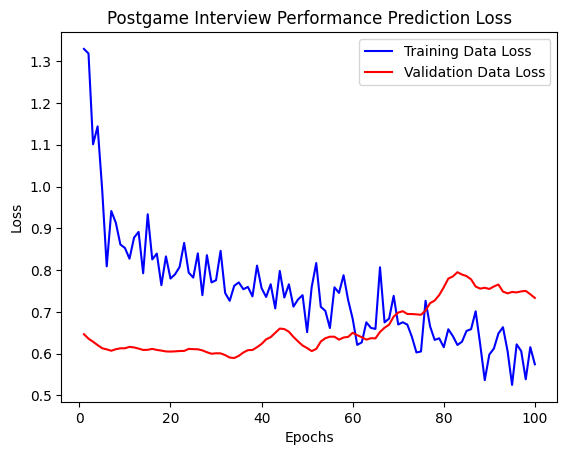

('cPFbGJwSzm', 0.127354, 0.0, 0.273138, 0.336619, 0.088874, 1e-06, 0.17401499999999998, -0.7130737360942687, -1.0779956944757556)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers

data_file = 'emotion_results.csv'
dtype = np.dtype([('id', 'U10'), ('avg_angry', float), ('avg_disgust', float), ('avg_fear', float), ('avg_happy', float), ('avg_sad', float), ('avg_surprise', float), ('avg_neutral', float), ('historical_gmsc_avg', float), ('next_game_gmsc', float )])
data = np.loadtxt(data_file, dtype=dtype, delimiter=',', skiprows=1, usecols=(2, 4, 5, 6, 7, 8, 9, 10, 13, 14))

# perform data normalization (scaling for emotions, standardization for gmsc)
emotion_fields = [
    'avg_angry',
    'avg_disgust',
    'avg_fear',
    'avg_happy',
    'avg_sad',
    'avg_surprise',
    'avg_neutral',
]
for field in emotion_fields:
    data[field] = data[field] / 100.0
data['historical_gmsc_avg'] = (data['historical_gmsc_avg'] - data['historical_gmsc_avg'].mean()) / data['historical_gmsc_avg'].std()
data['next_game_gmsc'] = (data['next_game_gmsc'] - data['next_game_gmsc'].mean()) / data['next_game_gmsc'].std()

# scramble data
np.random.shuffle(data)

# split data into training and testing sets
train_data = data[:int(len(data)*0.8)]
test_data = data[int(len(data)*0.8):]

# split data into features and labels
feature_names = data.dtype.names[1:-1]
x_train = np.array([train_data[name] for name in feature_names]).T
y_train = np.array(train_data['next_game_gmsc'])
x_test = np.array([test_data[name] for name in feature_names]).T
y_test = np.array(test_data['next_game_gmsc'])

model = keras.Sequential([
    layers.Input(shape=(x_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='tanh')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

model_history = model.fit(
    x_train, 
    y_train,
    epochs=100,
    batch_size=16,
    validation_data=(x_test, y_test)
)

# Print model loss graph
loss = model_history.history["loss"]
val_loss = model_history.history["val_loss"]
actual_epochs = range(1, len(loss) + 1)

# Use the new actual_epochs variable for the x-axis
plt.plot(actual_epochs, loss, "b-", label="Training Data Loss")
plt.plot(actual_epochs, val_loss, "r-", label="Validation Data Loss")

plt.title("Postgame Interview Performance Prediction Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# print test row
print(data[0])